In [54]:
# Cell 1 - Import Libraries & Load Data
print("📥 MEMUAT LIBRARY DAN DATA...")

import pandas as pd
import numpy as np
import re
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

print("✅ Libraries berhasil diimport!")

# Load data
try:
    df = pd.read_csv('comments.csv')
    print(f"✅ Berhasil load data: {len(df)} komentar")
    print(f"📊 Kolom: {list(df.columns)}")
    
    # Tampilkan sample
    print("\n📋 Sample data awal:")
    display(df.head(3))
    
except FileNotFoundError:
    print("❌ ERROR: File 'comments.csv' tidak ditemukan!")
except Exception as e:
    print(f"❌ ERROR: {e}")

📥 MEMUAT LIBRARY DAN DATA...
✅ Libraries berhasil diimport!
✅ Berhasil load data: 1139 komentar
📊 Kolom: ['video_id', 'author', 'comment', 'like_count', 'published']

📋 Sample data awal:


,video_id,author,comment,like_count,published
0,At9u_bDYIe0,@DelfitaBatam,Memangm. Mafia pajak mafia bea cukai mafia pol...,0,2025-11-19T05:44:39Z
1,At9u_bDYIe0,@AKIRATAMPAN,"Pak Purbaya antek"" wiwi dan wowo jd aku ngga p...",0,2025-11-19T02:48:12Z
2,At9u_bDYIe0,@madeceraka3537,Masyakat harus bersatu mendorong DPR untuk sec...,0,2025-11-19T01:58:47Z


In [55]:
# Cell 2 - Hapus Duplikasi
print("🧹 MENGHAPUS DUPLIKASI...")

print(f"📊 Data sebelum: {len(df)} komentar")

# Hapus duplikat
df = df.drop_duplicates()
print(f"✅ Duplikat dihapus")

# Hapus duplikat komentar
df = df.drop_duplicates(subset=['comment'])
print(f"✅ Duplikat komentar dihapus")

print(f"📊 Data sesudah: {len(df)} komentar")

🧹 MENGHAPUS DUPLIKASI...
📊 Data sebelum: 1139 komentar
✅ Duplikat dihapus
✅ Duplikat komentar dihapus
📊 Data sesudah: 1132 komentar


In [59]:
# Cell 3 - CLEANING YANG PASTI BERHASIL
print("🧼 CLEANING DENGAN METHOD TERBAIK...")

def clean_text_complete(text):
    if pd.isna(text):
        return ""
    
    text = str(text)
    
    # 1. HAPUS EMOJI - METHOD PALING AMPUH
    # Hapus semua karakter non-ASCII (termasuk emoji)
    text = text.encode('ascii', 'ignore').decode('ascii')
    
    # 2. HAPUS URL
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'www\S+', '', text)
    text = re.sub(r'https\S+', '', text)
    
    # 3. HAPUS MENTION & HASHTAG
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    
    # 4. HAPUS KARAKTER KHUSUS
    text = re.sub(r'[^\w\s]', ' ', text)  # Hapus semua yang bukan huruf/angka/spasi
    
    # 5. HAPUS EXTRA SPACES
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Test dengan sample yang ada emoji
print("🔍 TEST SEBELUM APPLY:")
test_samples = [
    "Suka video ini! 😊👍",
    "Bagus banget 💯❤️",
    "Luar biasa! 🎉🔥"
]

for sample in test_samples:
    cleaned = clean_text_complete(sample)
    print(f"   '{sample}' -> '{cleaned}'")

# Apply ke semua data
print("\n🎯 MENERAPKAN KE SEMUA DATA...")
df['comment_clean'] = df['comment'].apply(clean_text_complete)

# Verifikasi hasil
print("✅ Cleaning selesai!")

# Cek apakah masih ada emoji
def has_emoji(text):
    if pd.isna(text):
        return False
    return any(ord(char) > 127 for char in str(text))

emoji_count = df['comment_clean'].apply(has_emoji).sum()
print(f"🔍 Komentar dengan emoji setelah cleaning: {emoji_count}")

if emoji_count == 0:
    print("🎉 SEMUA EMOJI SUDAH HILANG!")
else:
    print("❌ MASIH ADA EMOJI - DEBUG:")
    problematic = df[df['comment_clean'].apply(has_emoji)]
    for idx, row in problematic[['comment', 'comment_clean']].head(3).iterrows():
        print(f"   Original: {row['comment']}")
        print(f"   Cleaned:  {row['comment_clean']}")
        # Tampilkan karakter problematic
        chars = [(c, ord(c)) for c in str(row['comment_clean']) if ord(c) > 127]
        print(f"   Chars: {chars}")

# Tampilkan sample hasil
print("\n📋 SAMPLE HASIL CLEANING:")
for i in range(min(3, len(df))):
    print(f"   BEFORE: {df.iloc[i]['comment']}")
    print(f"   AFTER:  {df.iloc[i]['comment_clean']}")
    print("   ---")

🧼 CLEANING DENGAN METHOD TERBAIK...
🔍 TEST SEBELUM APPLY:
   'Suka video ini! 😊👍' -> 'Suka video ini'
   'Bagus banget 💯❤️' -> 'Bagus banget'
   'Luar biasa! 🎉🔥' -> 'Luar biasa'

🎯 MENERAPKAN KE SEMUA DATA...
✅ Cleaning selesai!
🔍 Komentar dengan emoji setelah cleaning: 0
🎉 SEMUA EMOJI SUDAH HILANG!

📋 SAMPLE HASIL CLEANING:
   BEFORE: Memangm. Mafia pajak mafia bea cukai mafia polisi dan mafia di kantor kantor baik dipemerinttahan maupun daerah dan kelurahan tak bisadiberantas karena. Mereka saling melindungi satu sama sudah menjadi kebiasaan walaupun pergantian pejabat oleh sebab itu saya mendukung sekali gebrakan Pak Menkeu sekarang yg sebelum nya tak pernah ada gerakannya malah memberikan tambahan gaji dan memperkaya pada pejabat mereka
   AFTER:  Memangm Mafia pajak mafia bea cukai mafia polisi dan mafia di kantor kantor baik dipemerinttahan maupun daerah dan kelurahan tak bisadiberantas karena Mereka saling melindungi satu sama sudah menjadi kebiasaan walaupun pergantian pejabat 

In [60]:
# Cell 4 - Normalisasi Teks (FIXED)
print("🔠 NORMALISASI TEKS...")

# Setup stemmer
stemmer = PorterStemmer()

# Stopwords manual untuk bahasa Indonesia + Inggris
stop_words = set([
    # Indonesian stopwords
    'yang', 'dan', 'di', 'dari', 'dengan', 'untuk', 'pada', 'ke', 'dalam',
    'ini', 'itu', 'saya', 'kamu', 'kita', 'mereka', 'dia', 'aku', 'engkau',
    'ada', 'adalah', 'akan', 'telah', 'sudah', 'lagi', 'juga', 'saja',
    'atau', 'tapi', 'namun', 'jika', 'karena', 'sehingga', 'oleh', 'agar',
    'supaya', 'meski', 'walau', 'sambil', 'seraya', 'setelah', 'sebelum',
    'ketika', 'sejak', 'sampai', 'hingga', 'apabila', 'asalkan', 'jikalau',
    'yaitu', 'yakni', 'bahwa', 'agar', 'supaya', 'sementara', 'selama',
    'hingga', 'bila', 'mana', 'sebab', 'oleh', 'karena', 'sehingga',
    'dll', 'dsb', 'dkk', 'dgn', 'yg', 'utk', 'pd', 'sdh', 'tdk', 'ga',
    
    # English stopwords  
    'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for',
    'with', 'by', 'is', 'are', 'was', 'were', 'be', 'been', 'have', 'has',
    'had', 'do', 'does', 'did', 'will', 'would', 'could', 'should', 'may',
    'might', 'must', 'can', 'shall', 'this', 'that', 'these', 'those',
    'you', 'your', 'yours', 'me', 'my', 'mine', 'he', 'him', 'his', 'she',
    'her', 'hers', 'it', 'its', 'we', 'us', 'our', 'ours', 'they', 'them',
    'their', 'theirs'
])

print(f"🔧 Menggunakan {len(stop_words)} stopwords")

def normalize_text(text):
    if pd.isna(text) or text == "":
        return ""
    
    text = str(text)
    
    # 1. Lowercase
    text = text.lower()
    
    # 2. Hapus tanda baca dan angka
    text = re.sub(r'[^\w\s]', ' ', text)  # Hapus tanda baca
    text = re.sub(r'\d+', '', text)       # Hapus angka
    
    # 3. Tokenisasi (sederhana dengan split)
    tokens = text.split()
    
    # 4. Hapus stopwords dan kata terlalu pendek
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    
    # 5. Stemming
    tokens = [stemmer.stem(word) for word in tokens]
    
    # 6. Join kembali
    cleaned_text = ' '.join(tokens)
    
    # Hapus extra spaces
    cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()
    
    return cleaned_text

# Test dulu dengan sample yang mengandung emoji
test_text = "Saya suka video ini! 😊 https://example.com @user #bagus"
result = normalize_text(test_text)
print(f"🔍 Test: '{test_text}'")
print(f"   -> '{result}'")

# Terapkan ke data yang SUDAH DIBERSIHKAN dari Cell 3
df['comment_normalized'] = df['comment_clean'].apply(normalize_text)
print("✅ Teks dinormalisasi")

# Tampilkan sample hasil
print("\n📋 SAMPLE HASIL NORMALISASI:")
sample_df = df[['comment', 'comment_clean', 'comment_normalized']].head(5)
for idx, row in sample_df.iterrows():
    print(f"   Original: {row['comment']}")
    print(f"   Cleaned:  {row['comment_clean']}")
    print(f"   Normalized: {row['comment_normalized']}")
    print("   ---")

🔠 NORMALISASI TEKS...
🔧 Menggunakan 126 stopwords
🔍 Test: 'Saya suka video ini! 😊 https://example.com @user #bagus'
   -> 'suka video http exampl com user bagu'
✅ Teks dinormalisasi

📋 SAMPLE HASIL NORMALISASI:
   Original: Memangm. Mafia pajak mafia bea cukai mafia polisi dan mafia di kantor kantor baik dipemerinttahan maupun daerah dan kelurahan tak bisadiberantas karena. Mereka saling melindungi satu sama sudah menjadi kebiasaan walaupun pergantian pejabat oleh sebab itu saya mendukung sekali gebrakan Pak Menkeu sekarang yg sebelum nya tak pernah ada gerakannya malah memberikan tambahan gaji dan memperkaya pada pejabat mereka
   Cleaned:  Memangm Mafia pajak mafia bea cukai mafia polisi dan mafia di kantor kantor baik dipemerinttahan maupun daerah dan kelurahan tak bisadiberantas karena Mereka saling melindungi satu sama sudah menjadi kebiasaan walaupun pergantian pejabat oleh sebab itu saya mendukung sekali gebrakan Pak Menkeu sekarang yg sebelum nya tak pernah ada gerakannya malah

In [61]:
# Cell 5 - Simpan Hasil (FIXED)
print("💾 MENYIMPAN HASIL...")

# Hapus komentar kosong setelah normalisasi
sebelum = len(df)
df = df[df['comment_normalized'].str.len() > 0]
sesudah = len(df)
print(f"✅ Komentar kosong dihapus: {sebelum - sesudah}")

# Simpan data bersih
df.to_csv('comments_cleaned.csv', index=False)

print(f"✅ Data disimpan: {len(df)} komentar bersih")

# Tampilkan final sample
print("\n🎯 FINAL SAMPLE HASIL:")
final_samples = df[['comment', 'comment_normalized']].head(3)
for idx, row in final_samples.iterrows():
    print(f"   BEFORE: {row['comment']}")
    print(f"   AFTER:  {row['comment_normalized']}")
    print("   ---")

print(f"\n📊 TOTAL KOMENTAR BERSIH: {len(df)}")

💾 MENYIMPAN HASIL...
✅ Komentar kosong dihapus: 0
✅ Data disimpan: 1125 komentar bersih

🎯 FINAL SAMPLE HASIL:
   BEFORE: Memangm. Mafia pajak mafia bea cukai mafia polisi dan mafia di kantor kantor baik dipemerinttahan maupun daerah dan kelurahan tak bisadiberantas karena. Mereka saling melindungi satu sama sudah menjadi kebiasaan walaupun pergantian pejabat oleh sebab itu saya mendukung sekali gebrakan Pak Menkeu sekarang yg sebelum nya tak pernah ada gerakannya malah memberikan tambahan gaji dan memperkaya pada pejabat mereka
   AFTER:  memangm mafia pajak mafia bea cukai mafia polisi mafia kantor kantor baik dipemerinttahan maupun daerah kelurahan tak bisadiberanta sale melindungi satu sama menjadi kebiasaan walaupun pergantian pejabat mendukung sekali gebrakan pak menkeu sekarang nya tak pernah gerakannya malah memberikan tambahan gaji memperkaya pejabat
   ---
   BEFORE: Pak Purbaya antek" wiwi dan wowo jd aku ngga percaya dgn ketiga org ini 👌
   AFTER:  pak purbaya antek wiwi wo

In [62]:
# Cell 6 - EKSPLORASI DATA SEDERHANA
print("📊 EKSPLORASI DATA")
print("=" * 40)

# 1. Hitung jumlah komentar, like, user unik
print("1. JUMLAH DATA:")
print(f"   • Komentar: {len(df)}")
print(f"   • Like total: {df['like_count'].sum()}")
print(f"   • User unik: {df['author'].nunique()}")

# 2. Statistik dasar
print("\n2. STATISTIK DASAR:")
print(f"   • Panjang komentar rata-rata: {df['comment_clean'].str.len().mean():.1f} karakter")
print(f"   • Like rata-rata: {df['like_count'].mean():.1f}")
print(f"   • Like tertinggi: {df['like_count'].max()}")

# 3. Cek missing value
print("\n3. MISSING VALUES:")
missing = df.isnull().sum()
for col in missing.index:
    if missing[col] > 0:
        print(f"   • {col}: {missing[col]}")

print("=" * 40)

📊 EKSPLORASI DATA
1. JUMLAH DATA:
   • Komentar: 1125
   • Like total: 2158
   • User unik: 965

2. STATISTIK DASAR:
   • Panjang komentar rata-rata: 138.5 karakter
   • Like rata-rata: 1.9
   • Like tertinggi: 99

3. MISSING VALUES:
   • author: 1


📈 VISUALISASI SEDERHANA


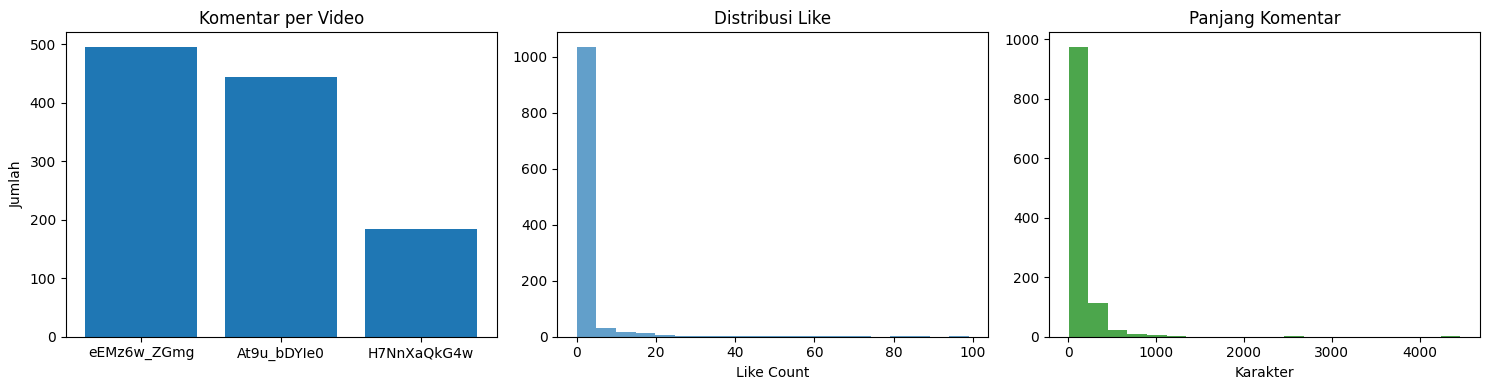

In [63]:
# Cell 7 - VISUALISASI SEDERHANA
print("📈 VISUALISASI SEDERHANA")

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Komentar per video
video_counts = df['video_id'].value_counts()
axes[0].bar(video_counts.index, video_counts.values)
axes[0].set_title('Komentar per Video')
axes[0].set_ylabel('Jumlah')

# 2. Distribusi like
axes[1].hist(df['like_count'], bins=20, alpha=0.7)
axes[1].set_title('Distribusi Like')
axes[1].set_xlabel('Like Count')

# 3. Panjang komentar
axes[2].hist(df['comment_clean'].str.len(), bins=20, alpha=0.7, color='green')
axes[2].set_title('Panjang Komentar')
axes[2].set_xlabel('Karakter')

plt.tight_layout()
plt.show()

📝 ANALISIS KATA SERING MUNCUL
15 KATA PALING SERING MUNCUL:
   rakyat: 355x
   pak: 337x
   purbaya: 283x
   negara: 279x
   indonesia: 265x
   mafia: 192x
   prabowo: 161x
   bisa: 152x
   para: 143x
   nya: 121x
   presiden: 120x
   semua: 112x
   orang: 111x
   haru: 105x
   tidak: 104x


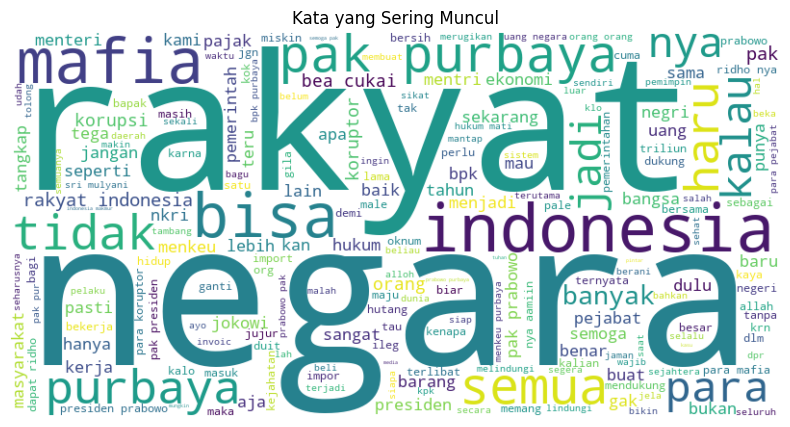

In [65]:
# Cell 8 - ANALISIS KATA SERING MUNCUL
print("📝 ANALISIS KATA SERING MUNCUL")

from collections import Counter

# Gabungkan semua komentar
all_text = ' '.join(df['comment_normalized'])
words = all_text.split()

# Hitung frekuensi kata
word_freq = Counter(words)
top_words = word_freq.most_common(15)

print("15 KATA PALING SERING MUNCUL:")
for word, count in top_words:
    print(f"   {word}: {count}x")

# Wordcloud sederhana (opsional)
try:
    from wordcloud import WordCloud
    import matplotlib.pyplot as plt
    
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Kata yang Sering Muncul')
    plt.show()
    
except ImportError:
    print("WordCloud tidak tersedia, skip visualisasi")

In [66]:
# Cell 9 - ANALISIS SENTIMEN SEDERHANA
print("🎭 ANALISIS SENTIMEN")

# Kamus sentimen sederhana
positive_words = ['bagus', 'baik', 'sukses', 'mantap', 'keren', 'hebat', 'suka', 'senang', 'puas', 'recommend']
negative_words = ['jelek', 'buruk', 'gagal', 'mengecewakan', 'bosan', 'tidak', 'jangan', 'hindari', 'susah', 'ribet']

def simple_sentiment(text):
    text = str(text).lower()
    positive_count = sum(1 for word in positive_words if word in text)
    negative_count = sum(1 for word in negative_words if word in text)
    
    if positive_count > negative_count:
        return 'positif'
    elif negative_count > positive_count:
        return 'negatif'
    else:
        return 'netral'

# Terapkan analisis sentimen
df['sentiment'] = df['comment_normalized'].apply(simple_sentiment)

# Tampilkan hasil
sentiment_counts = df['sentiment'].value_counts()
print("DISTRIBUSI SENTIMEN:")
for sentiment, count in sentiment_counts.items():
    percentage = (count / len(df)) * 100
    print(f"   {sentiment}: {count} komentar ({percentage:.1f}%)")

🎭 ANALISIS SENTIMEN
DISTRIBUSI SENTIMEN:
   netral: 897 komentar (79.7%)
   negatif: 129 komentar (11.5%)
   positif: 99 komentar (8.8%)


In [67]:
# Cell 10 - TOPIC MODELING SEDERHANA
print("🗂️ TOPIC MODELING SEDERHANA")

# Group komentar berdasarkan kata kunci
def detect_topic(text):
    text = str(text).lower()
    
    if any(word in text for word in ['pemerintah', 'politik', 'negara', 'presiden']):
        return 'Politik'
    elif any(word in text for word in ['video', 'konten', 'channel', 'tonton']):
        return 'Konten Video'
    elif any(word in text for word in ['terima kasih', 'sukses', 'dukung', 'support']):
        return 'Dukungan'
    else:
        return 'Lainnya'

# Terapkan topic detection
df['topic'] = df['comment_normalized'].apply(detect_topic)

# Tampilkan distribusi topic
topic_counts = df['topic'].value_counts()
print("DISTRIBUSI TOPIC:")
for topic, count in topic_counts.items():
    percentage = (count / len(df)) * 100
    print(f"   {topic}: {count} komentar ({percentage:.1f}%)")

# Tampilkan sample per topic
print("\nSAMPLE PER TOPIC:")
for topic in df['topic'].unique():
    sample = df[df['topic'] == topic]['comment_normalized'].iloc[0]
    print(f"   {topic}: {sample}")

🗂️ TOPIC MODELING SEDERHANA
DISTRIBUSI TOPIC:
   Lainnya: 733 komentar (65.2%)
   Politik: 348 komentar (30.9%)
   Dukungan: 44 komentar (3.9%)

SAMPLE PER TOPIC:
   Dukungan: memangm mafia pajak mafia bea cukai mafia polisi mafia kantor kantor baik dipemerinttahan maupun daerah kelurahan tak bisadiberanta sale melindungi satu sama menjadi kebiasaan walaupun pergantian pejabat mendukung sekali gebrakan pak menkeu sekarang nya tak pernah gerakannya malah memberikan tambahan gaji memperkaya pejabat
   Lainnya: pak purbaya antek wiwi wowo ngga percaya ketiga org
   Politik: ternyata banyak sekali jabatan negeri dipegang orang orang jahat sangat biadab panta negara sangat sulit maju walaupun sumber daya alam nya sangat melimpah ruah


📊 VISUALISASI DATA


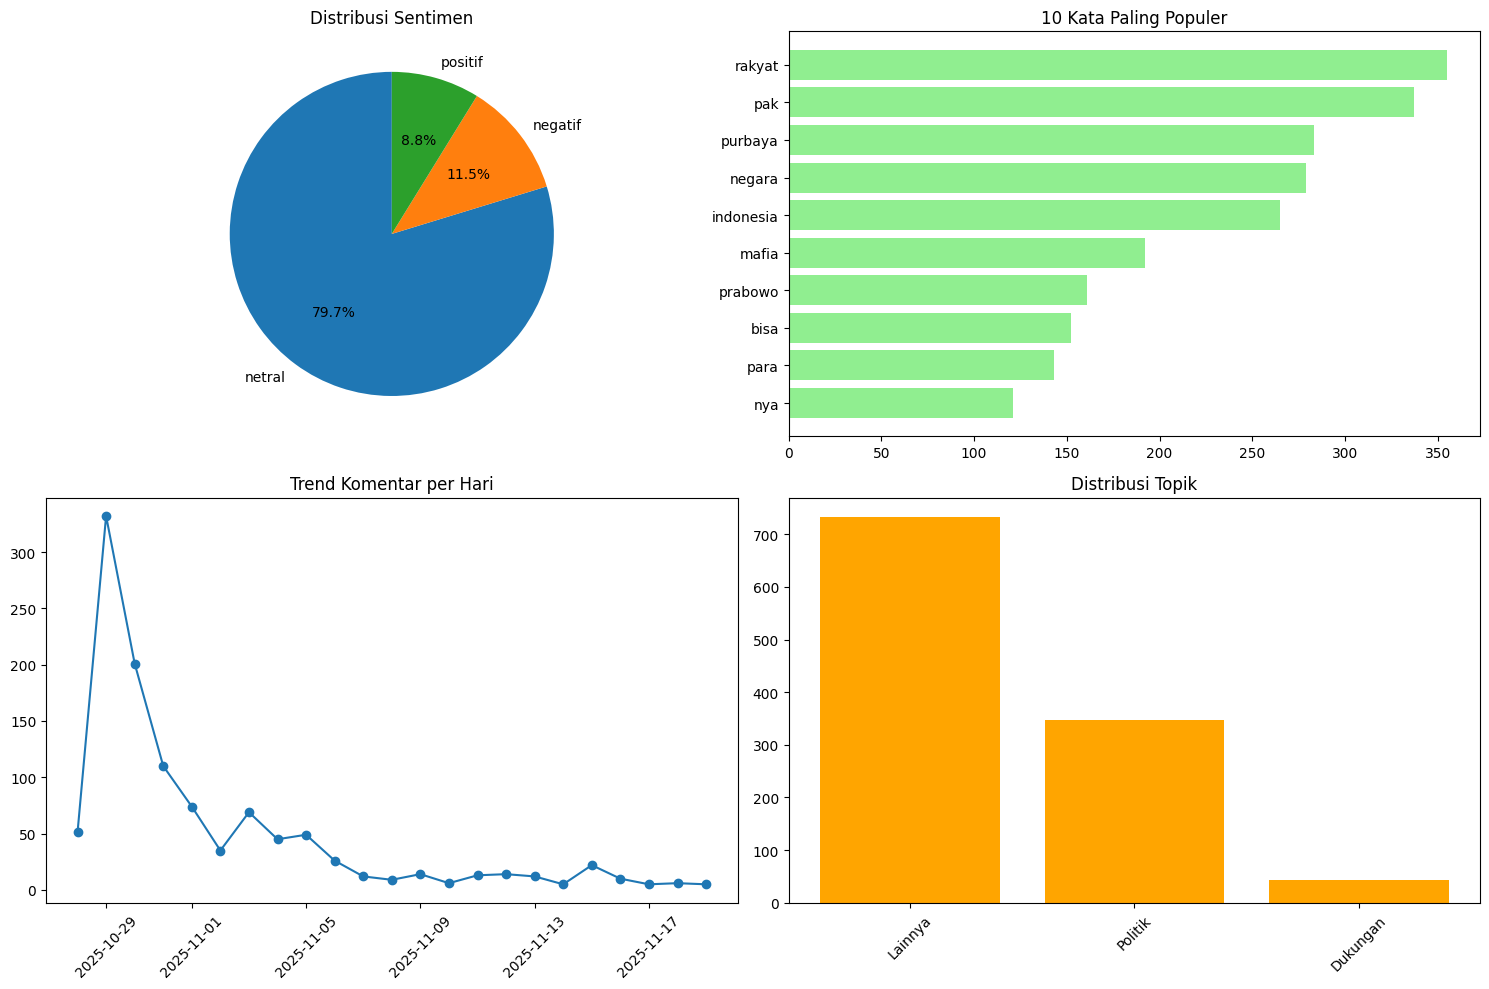

In [68]:
# Cell 12 - VISUALISASI SEDERHANA
print("📊 VISUALISASI DATA")

import matplotlib.pyplot as plt

# Buat figure dengan 3 subplot
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Pie Chart Sentimen
sentiment_counts = df['sentiment'].value_counts()
axes[0,0].pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=90)
axes[0,0].set_title('Distribusi Sentimen')

# 2. Bar Chart Kata Populer
from collections import Counter
all_text = ' '.join(df['comment_normalized'])
top_words = Counter(all_text.split()).most_common(10)
words, counts = zip(*top_words)
axes[0,1].barh(words, counts, color='lightgreen')
axes[0,1].set_title('10 Kata Paling Populer')
axes[0,1].invert_yaxis()

# 3. Line Chart Trend Komentar (jika ada kolom datetime)
try:
    df['date'] = pd.to_datetime(df['published']).dt.date
    daily_counts = df['date'].value_counts().sort_index()
    axes[1,0].plot(daily_counts.index, daily_counts.values, marker='o')
    axes[1,0].set_title('Trend Komentar per Hari')
    axes[1,0].tick_params(axis='x', rotation=45)
except:
    axes[1,0].text(0.5, 0.5, 'Data waktu tidak tersedia', ha='center', va='center')
    axes[1,0].set_title('Trend Komentar')

# 4. Bar Chart Topik
topic_counts = df['topic'].value_counts()
axes[1,1].bar(topic_counts.index, topic_counts.values, color='orange')
axes[1,1].set_title('Distribusi Topik')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

☁️ MEMBUAT WORDCLOUD


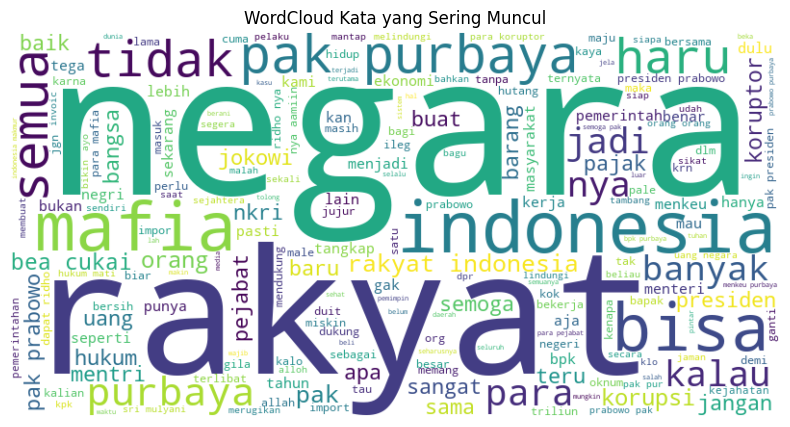

In [69]:
# Cell 13 - WORDCLOUD (OPSIONAL)
print("☁️ MEMBUAT WORDCLOUD")

try:
    from wordcloud import WordCloud
    
    all_text = ' '.join(df['comment_normalized'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('WordCloud Kata yang Sering Muncul')
    plt.show()
    
except ImportError:
    print("WordCloud tidak terinstall, skip visualisasi")

💾 SIMPAN SEMUA GRAFIK DAN DATA
✅ Data analisis disimpan: youtube_comments_analyzed.csv
✅ Summary disimpan: analysis_summary.csv
📊 Menyimpan semua grafik...
✅ Grafik 1: sentiment_pie.png
✅ Grafik 2: top_words.png
✅ Grafik 3: topic_distribution.png
✅ Grafik 4: comments_per_video.png
✅ Grafik 5: wordcloud.png

📁 SEMUA FILE DISIMPAN:
   • youtube_comments_analyzed.csv - Data lengkap
   • analysis_summary.csv - Summary statistics
   • sentiment_pie.png - Pie chart sentimen
   • top_words.png - Bar chart kata populer
   • topic_distribution.png - Distribusi topik
   • comments_per_video.png - Komentar per video
   • wordcloud.png - WordCloud kata sering muncul

🎉 ANALISIS SELESAI! Total 1125 komentar dianalisis.


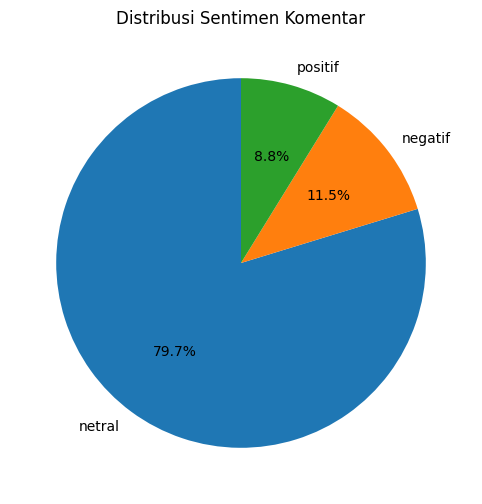

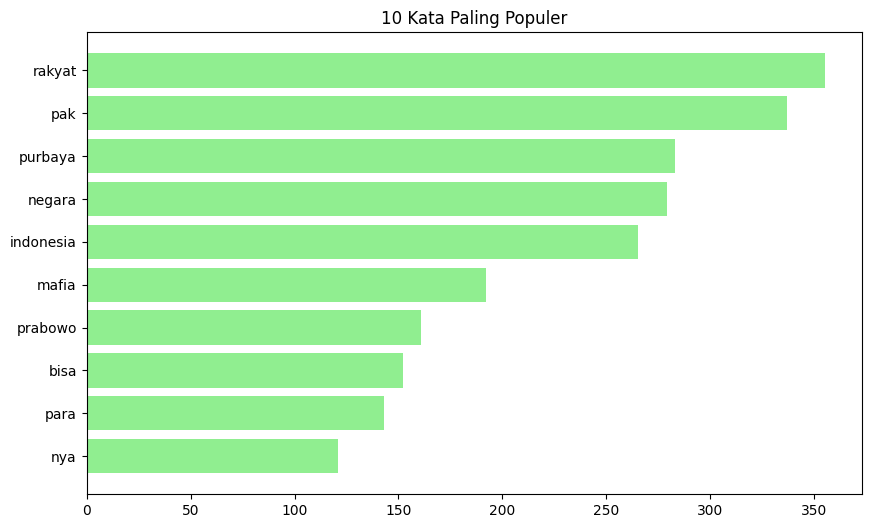

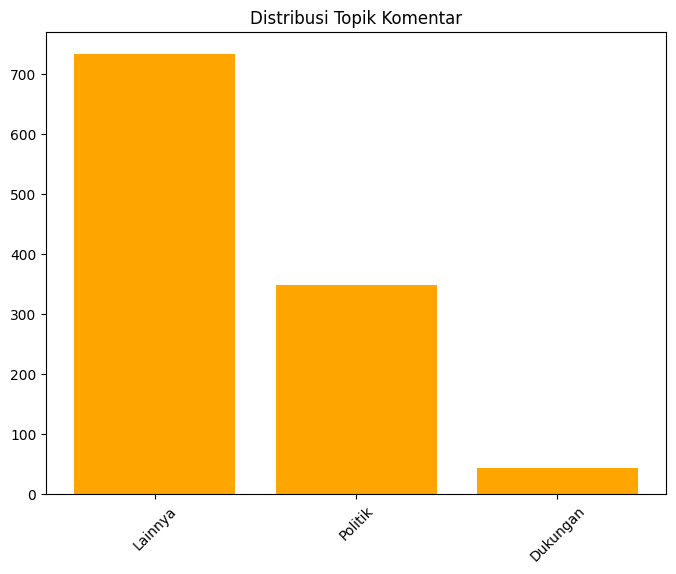

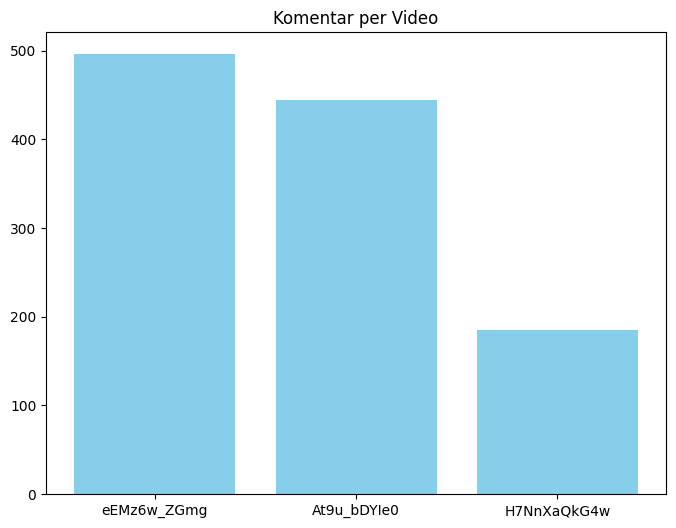

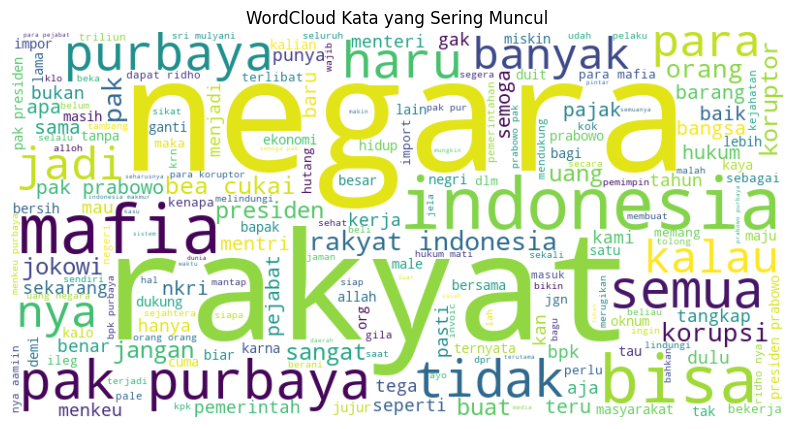

In [72]:
# Cell 14 - SIMPAN SEMUA GRAFIK TERMASUK WORDCLOUD
print("💾 SIMPAN SEMUA GRAFIK DAN DATA")

import matplotlib.pyplot as plt
from collections import Counter

# 1. Simpan data bersih ke CSV
df.to_csv('youtube_comments_analyzed.csv', index=False)
print("✅ Data analisis disimpan: youtube_comments_analyzed.csv")

# 2. Simpan summary statistics
summary = {
    'total_comments': len(df),
    'unique_users': df['author'].nunique(),
    'total_likes': df['like_count'].sum(),
    'avg_comment_length': df['comment_normalized'].str.len().mean(),
    'dominant_sentiment': df['sentiment'].value_counts().index[0],
    'dominant_topic': df['topic'].value_counts().index[0]
}
summary_df = pd.DataFrame([summary])
summary_df.to_csv('analysis_summary.csv', index=False)
print("✅ Summary disimpan: analysis_summary.csv")

# 3. Simpan semua grafik
print("📊 Menyimpan semua grafik...")

# Grafik 1: Sentimen
plt.figure(figsize=(8, 6))
sentiment_counts = df['sentiment'].value_counts()
plt.pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribusi Sentimen Komentar')
plt.savefig('sentiment_pie.png', dpi=100, bbox_inches='tight')
print("✅ Grafik 1: sentiment_pie.png")

# Grafik 2: Kata Populer
plt.figure(figsize=(10, 6))
all_text = ' '.join(df['comment_normalized'])
top_words = Counter(all_text.split()).most_common(10)
words, counts = zip(*top_words)
plt.barh(words, counts, color='lightgreen')
plt.title('10 Kata Paling Populer')
plt.gca().invert_yaxis()
plt.savefig('top_words.png', dpi=100, bbox_inches='tight')
print("✅ Grafik 2: top_words.png")

# Grafik 3: Distribusi Topik
plt.figure(figsize=(8, 6))
topic_counts = df['topic'].value_counts()
plt.bar(topic_counts.index, topic_counts.values, color='orange')
plt.title('Distribusi Topik Komentar')
plt.xticks(rotation=45)
plt.savefig('topic_distribution.png', dpi=100, bbox_inches='tight')
print("✅ Grafik 3: topic_distribution.png")

# Grafik 4: Komentar per Video
plt.figure(figsize=(8, 6))
video_counts = df['video_id'].value_counts()
plt.bar(video_counts.index, video_counts.values, color='skyblue')
plt.title('Komentar per Video')
plt.savefig('comments_per_video.png', dpi=100, bbox_inches='tight')
print("✅ Grafik 4: comments_per_video.png")

# Grafik 5: WordCloud
try:
    from wordcloud import WordCloud
    plt.figure(figsize=(10, 6))
    all_text = ' '.join(df['comment_normalized'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('WordCloud Kata yang Sering Muncul')
    plt.savefig('wordcloud.png', dpi=100, bbox_inches='tight')
    print("✅ Grafik 5: wordcloud.png")
except ImportError:
    print("❌ WordCloud tidak terinstall, skip")

print(f"\n📁 SEMUA FILE DISIMPAN:")
print("   • youtube_comments_analyzed.csv - Data lengkap")
print("   • analysis_summary.csv - Summary statistics")
print("   • sentiment_pie.png - Pie chart sentimen")
print("   • top_words.png - Bar chart kata populer") 
print("   • topic_distribution.png - Distribusi topik")
print("   • comments_per_video.png - Komentar per video")
print("   • wordcloud.png - WordCloud kata sering muncul")
print(f"\n🎉 ANALISIS SELESAI! Total {len(df)} komentar dianalisis.")